In [111]:
bed_availability = pd.Series({
    'Yatak bilgisi hiç olmayan konum': (
        bed_check['dolu_yatak_kaydi'].eq(0).sum()#eq sıfıra eşit mi?
    ),
    'Yatak bilgisi bulunan konum': (
        bed_check['dolu_yatak_kaydi'].gt(0).sum()#0'dan büyük mü
    )
})

print(bed_availability)

Yatak bilgisi hiç olmayan konum     67
Yatak bilgisi bulunan konum        172
dtype: int64


In [112]:
bed_data_locations = bed_check.loc[
    bed_check['dolu_yatak_kaydi'].gt(0)
]

bed_needs_review = bed_data_locations.loc[
    (bed_data_locations['dolu_yatak_kaydi']
     < bed_data_locations['toplam_satir'])
    | (bed_data_locations['farkli_yatak_degeri'].ne(1))
    | (bed_data_locations['en_dusuk_yatak'].le(0))
]

print(bed_needs_review)

Empty DataFrame
Columns: [toplam_satir, dolu_yatak_kaydi, farkli_yatak_degeri, en_dusuk_yatak, en_yuksek_yatak]
Index: []


In [113]:
bed_capacity = (
    bed_data_locations[
        ['en_dusuk_yatak']
    ]
    .rename(
        columns={
            'en_dusuk_yatak': 'yatak_bin_kisi_basina'
        }
    )
)

print('En yüksek yatak kapasitesi:')
print(
    bed_capacity
    .sort_values('yatak_bin_kisi_basina', ascending=False)
    .head(10)
)

print('\nEn düşük yatak kapasitesi:')
print(
    bed_capacity
    .sort_values('yatak_bin_kisi_basina')
    .head(10)
)

En yüksek yatak kapasitesi:
              yatak_bin_kisi_basina
location                           
Monaco                        13.80
North Korea                   13.20
Japan                         13.05
South Korea                   12.27
Belarus                       11.00
Ukraine                        8.80
Russia                         8.05
Germany                        8.00
Bulgaria                       7.45
Turkmenistan                   7.40

En düşük yatak kapasitesi:
              yatak_bin_kisi_basina
location                           
Mali                            0.1
Madagascar                      0.2
Ethiopia                        0.3
Nepal                           0.3
Guinea                          0.3
Niger                           0.3
Burkina Faso                    0.4
Benin                           0.5
Afghanistan                     0.5
Uganda                          0.5


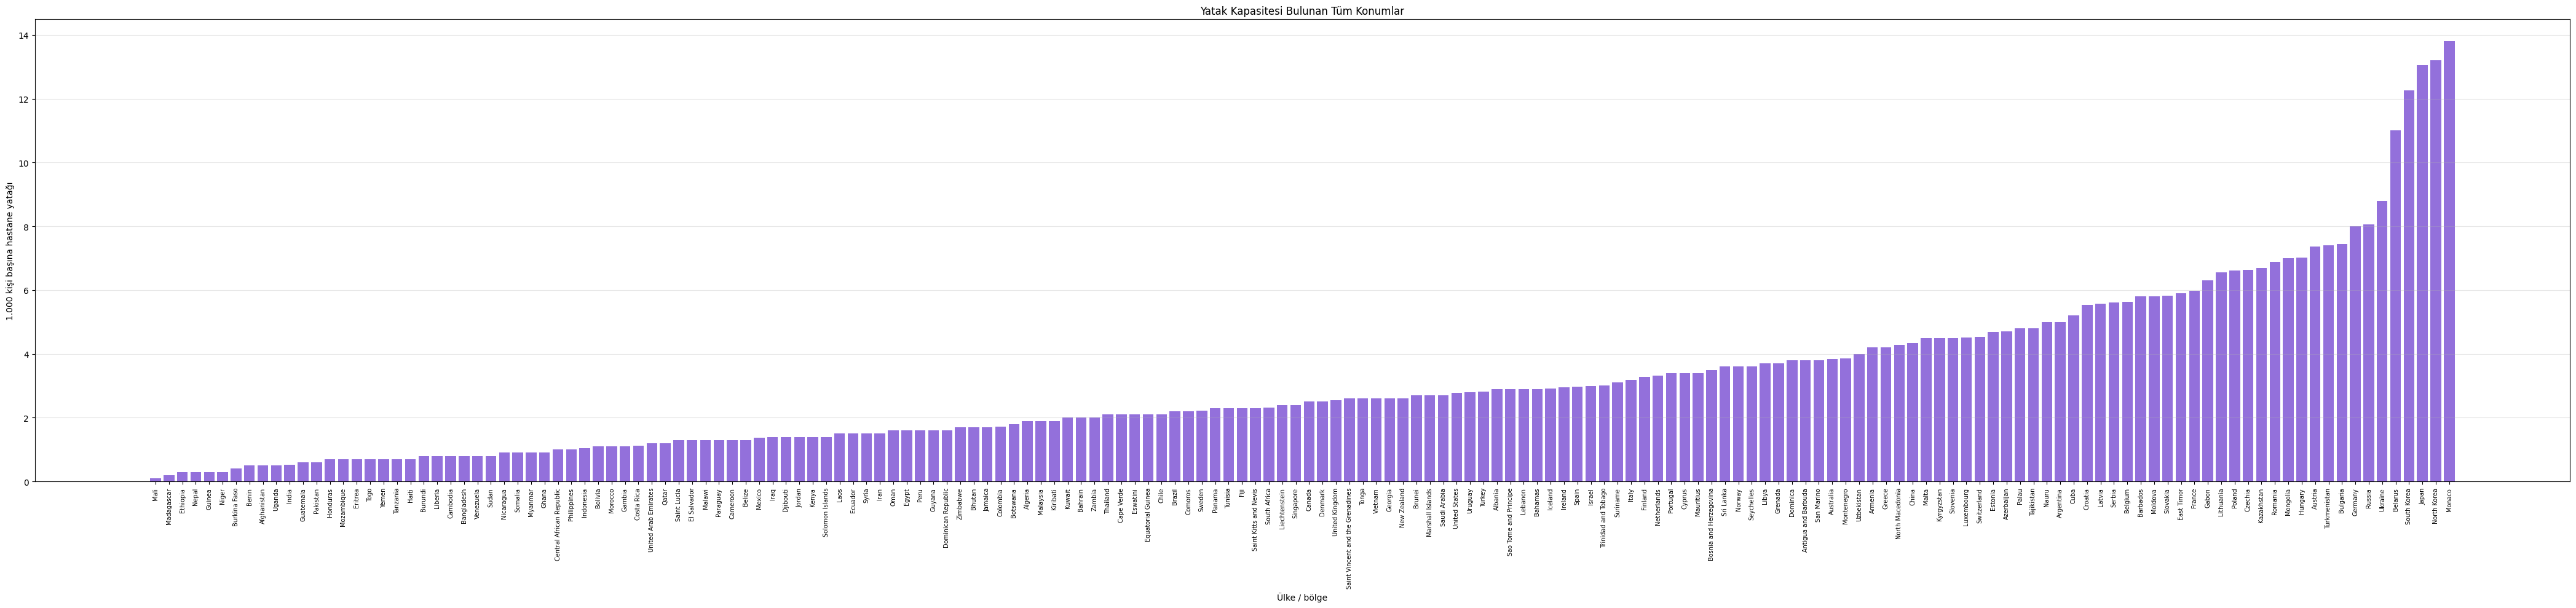

In [114]:
#yatak bilgisi girilen  ülkeleri bin kişi başına hesaplanması
all_bed_capacity = (
    bed_capacity
    .sort_values('yatak_bin_kisi_basina')
)

fig, ax = plt.subplots(figsize=(42, 10))

ax.bar(
    all_bed_capacity.index,
    all_bed_capacity['yatak_bin_kisi_basina'],
    color='mediumpurple'
)

ax.set_title('Yatak Kapasitesi Bulunan Tüm Konumlar')
ax.set_xlabel('Ülke / bölge')
ax.set_ylabel('1.000 kişi başına hastane yatağı')

ax.tick_params(
    axis='x',
    labelrotation=90,
    labelsize=7
)

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [115]:
#hastane ve yoğun bakımdaki hasta sayısının incelenmesi
patient_coverage = df_countries.groupby('location').agg(
    toplam_satir=('date', 'size'),
    dolu_hastane_hasta_kaydi=('hosp_patients', 'count'),
    dolu_yogun_bakim_kaydi=('icu_patients', 'count')
)

patient_coverage['bos_hastane_hasta_kaydi'] = (
    patient_coverage['toplam_satir']
    - patient_coverage['dolu_hastane_hasta_kaydi']
)

patient_coverage['bos_yogun_bakim_kaydi'] = (
    patient_coverage['toplam_satir']
    - patient_coverage['dolu_yogun_bakim_kaydi']
)

print(
    patient_coverage
    .sort_values('dolu_hastane_hasta_kaydi', ascending=False)
    .head(15)
)

                toplam_satir  dolu_hastane_hasta_kaydi  \
location                                                 
Italy                   1677                      1627   
Czechia                 1682                      1616   
Malaysia                1684                      1597   
Sweden                  1674                      1485   
Canada                  1674                      1456   
United States           1674                      1381   
Australia               1674                      1347   
Belgium                 1674                      1209   
United Kingdom          1674                      1198   
Serbia                  1674                      1194   
Austria                 1674                      1186   
Estonia                 1682                      1164   
Israel                  1674                      1162   
Denmark                 1674                      1152   
Switzerland             1674                      1128   

             

In [116]:
italy_patients = (
    df_countries.loc[
        df_countries['location'].eq('Italy'),
        ['date', 'hosp_patients', 'icu_patients']
    ]
    .sort_values('date')
    .copy()
)

italy_valid_patient_dates = italy_patients.loc[
    italy_patients['hosp_patients'].notna()
    & italy_patients['icu_patients'].notna(),
    'date'
]

italy_missing_patient_dates = italy_patients.loc[
    italy_patients['hosp_patients'].isna()
    | italy_patients['icu_patients'].isna(),
    'date'
]

print('İlk iki verinin birlikte bulunduğu tarih:', italy_valid_patient_dates.min())
print('Son iki verinin birlikte bulunduğu tarih:', italy_valid_patient_dates.max())
print('Boş gün sayısı:', italy_missing_patient_dates.size)

İlk iki verinin birlikte bulunduğu tarih: 2020-02-24 00:00:00
Son iki verinin birlikte bulunduğu tarih: 2024-08-07 00:00:00
Boş gün sayısı: 50


In [117]:
italy_interior_missing_patients = italy_patients.loc[
    italy_patients['date'].between(
        italy_valid_patient_dates.min(),
        italy_valid_patient_dates.max()
    )
    & (
        italy_patients['hosp_patients'].isna()
        | italy_patients['icu_patients'].isna()
    ),
    ['date', 'hosp_patients', 'icu_patients']
]

print(italy_interior_missing_patients)

Empty DataFrame
Columns: [date, hosp_patients, icu_patients]
Index: []


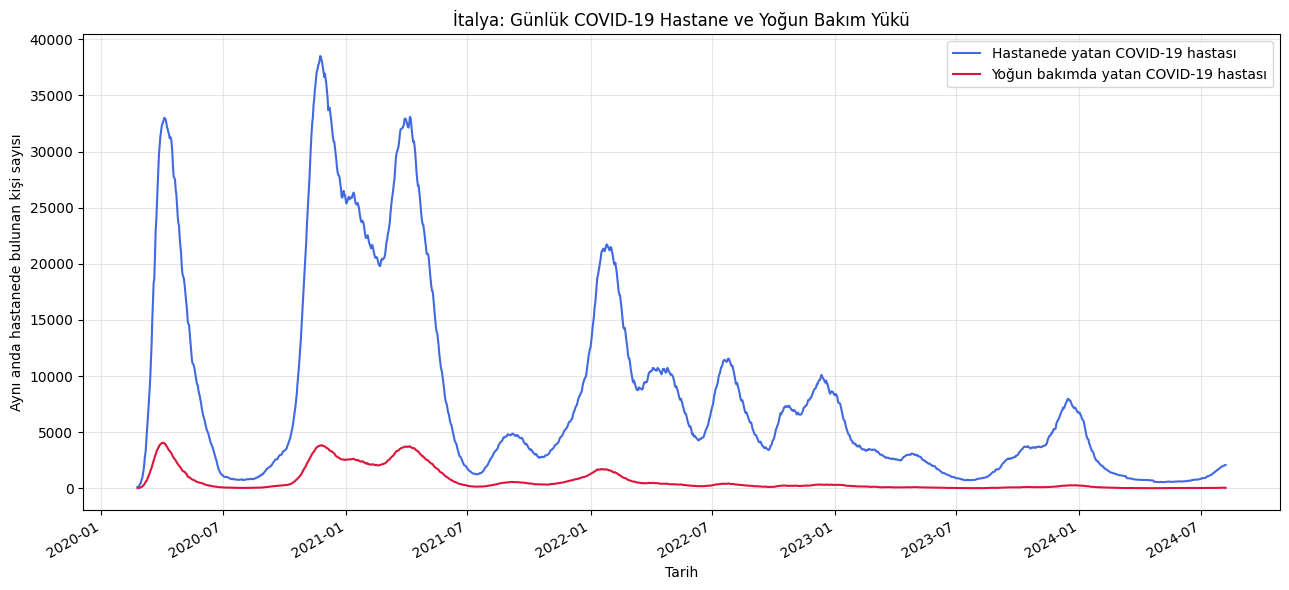

In [118]:
italy_patients_complete = italy_patients.dropna(
    subset=['hosp_patients', 'icu_patients']
).copy()

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    italy_patients_complete['date'],
    italy_patients_complete['hosp_patients'],
    color='royalblue',
    linewidth=1.5,
    label='Hastanede yatan COVID-19 hastası'
)

ax.plot(
    italy_patients_complete['date'],
    italy_patients_complete['icu_patients'],
    color='crimson',
    linewidth=1.5,
    label='Yoğun bakımda yatan COVID-19 hastası'
)

ax.set_title('İtalya: Günlük COVID-19 Hastane ve Yoğun Bakım Yükü')
ax.set_xlabel('Tarih')
ax.set_ylabel('Aynı anda hastanede bulunan kişi sayısı')

ax.ticklabel_format(axis='y', style='plain')
ax.grid(alpha=0.3)
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [119]:
italy_hospital_peak = italy_patients_complete.loc[
    italy_patients_complete['hosp_patients'].idxmax(),
    ['date', 'hosp_patients']
]

italy_icu_peak = italy_patients_complete.loc[
    italy_patients_complete['icu_patients'].idxmax(),
    ['date', 'icu_patients']
]

print('Hastane yükü zirvesi:')
print(italy_hospital_peak)

print('\nYoğun bakım yükü zirvesi:')
print(italy_icu_peak)

Hastane yükü zirvesi:
date             2020-11-23 00:00:00
hosp_patients                38507.0
Name: 169405, dtype: object

Yoğun bakım yükü zirvesi:
date            2020-04-03 00:00:00
icu_patients                 4068.0
Name: 169171, dtype: object


In [120]:
#hastanede olan hasta ve yoğun bakımda olan hastaların incelenmesi
patient_per_million_coverage = df_countries.groupby('location').agg(
    toplam_satir=('date', 'size'),
    dolu_hastane_milyon_kaydi=('hosp_patients_per_million', 'count'),
    dolu_yogun_bakim_milyon_kaydi=('icu_patients_per_million', 'count')
)

patient_per_million_coverage['bos_hastane_milyon_kaydi'] = (
    patient_per_million_coverage['toplam_satir']
    - patient_per_million_coverage['dolu_hastane_milyon_kaydi']
)

patient_per_million_coverage['bos_yogun_bakim_milyon_kaydi'] = (
    patient_per_million_coverage['toplam_satir']
    - patient_per_million_coverage['dolu_yogun_bakim_milyon_kaydi']
)

print(
    patient_per_million_coverage
    .sort_values('dolu_hastane_milyon_kaydi', ascending=False)
    .head(15)
)

                toplam_satir  dolu_hastane_milyon_kaydi  \
location                                                  
Italy                   1677                       1627   
Czechia                 1682                       1616   
Malaysia                1684                       1597   
Sweden                  1674                       1485   
Canada                  1674                       1456   
United States           1674                       1381   
Australia               1674                       1347   
Belgium                 1674                       1209   
United Kingdom          1674                       1198   
Serbia                  1674                       1194   
Austria                 1674                       1186   
Estonia                 1682                       1164   
Israel                  1674                       1162   
Denmark                 1674                       1152   
Switzerland             1674                       1128 

In [121]:
patient_per_million_daily = (
    df_countries[
        [
            'location',
            'date',
            'hosp_patients_per_million',
            'icu_patients_per_million'
        ]
    ]
    .dropna(
        subset=[
            'hosp_patients_per_million',
            'icu_patients_per_million'
        ]
    )
    .copy()
)

patient_date_coverage = (
    patient_per_million_daily
    .groupby('date')['location']
    .nunique()
    .sort_values(ascending=False)
)

print(patient_date_coverage.head(10))

date
2022-01-16    30
2022-01-30    30
2022-02-06    30
2022-02-13    30
2022-01-09    30
2022-02-27    29
2021-06-27    29
2022-03-13    29
2021-10-03    29
2021-12-05    29
Name: location, dtype: int64


In [122]:
import numpy as np

selected_patient_date = pd.Timestamp('2022-01-16')

patient_comparison_day = (
    patient_per_million_daily.loc[
        patient_per_million_daily['date'].eq(selected_patient_date),
        [
            'location',
            'hosp_patients_per_million',
            'icu_patients_per_million'
        ]
    ]
    .sort_values('hosp_patients_per_million')
    .copy()
)

print(patient_comparison_day.to_string(index=False))

      location  hosp_patients_per_million  icu_patients_per_million
   Netherlands                      33.88                     13.95
      Malaysia                      67.42                      5.51
       Austria                      99.67                     23.72
    Luxembourg                     109.64                     30.88
       Finland                     122.73                     11.37
        Sweden                     123.32                      9.48
       Denmark                     124.78                     10.03
  South Africa                     132.33                     10.79
       Bolivia                     148.07                     14.81
       Czechia                     158.95                     31.73
      Portugal                     176.52                     16.36
       Belgium                     186.86                     33.54
     Australia                     192.80                     15.70
       Ireland                     210.03       

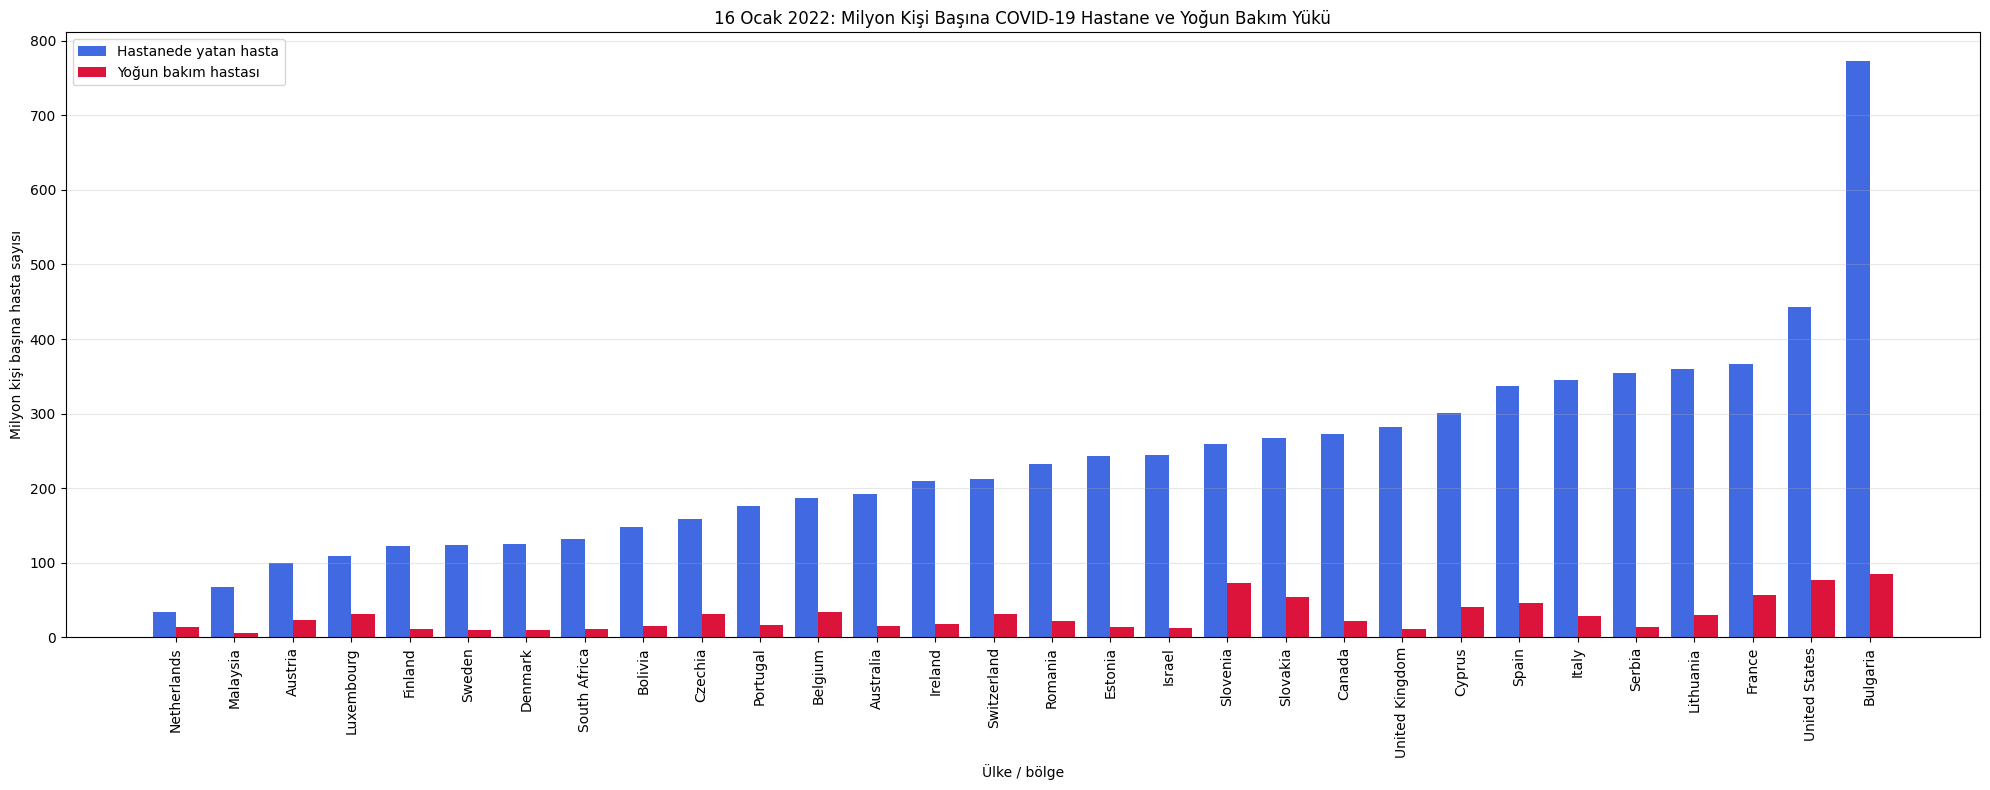

In [123]:
x = np.arange(len(patient_comparison_day))
bar_width = 0.4

fig, ax = plt.subplots(figsize=(20, 8))

ax.bar(
    x - bar_width / 2,
    patient_comparison_day['hosp_patients_per_million'],
    width=bar_width,
    color='royalblue',
    label='Hastanede yatan hasta'
)

ax.bar(
    x + bar_width / 2,
    patient_comparison_day['icu_patients_per_million'],
    width=bar_width,
    color='crimson',
    label='Yoğun bakım hastası'
)

ax.set_title(
    '16 Ocak 2022: Milyon Kişi Başına COVID-19 Hastane ve Yoğun Bakım Yükü'
)
ax.set_xlabel('Ülke / bölge')
ax.set_ylabel('Milyon kişi başına hasta sayısı')

ax.set_xticks(x)
ax.set_xticklabels(
    patient_comparison_day['location'],
    rotation=90
)

ax.grid(axis='y', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [173]:
#reproduction_rate:COVID-19 'un yayılma hızını gösteren R değeridir.
reproduction_coverage = (
    df_countries
    .groupby('location')
    .agg(
        toplam_satir=('date', 'size'),
        dolu_r_kaydi=('reproduction_rate', 'count'),
        ilk_r_tarihi=('date', lambda x: x[
            df_countries.loc[x.index, 'reproduction_rate'].notna()
        ].min()),
        son_r_tarihi=('date', lambda x: x[
            df_countries.loc[x.index, 'reproduction_rate'].notna()
        ].max())
    )
)

reproduction_coverage['bos_r_kaydi'] = (
    reproduction_coverage['toplam_satir']
    - reproduction_coverage['dolu_r_kaydi']
)

print(
    reproduction_coverage
    .sort_values('dolu_r_kaydi', ascending=False)
    .head(20)
)

                toplam_satir  dolu_r_kaydi ilk_r_tarihi son_r_tarihi  \
location                                                               
China                   1674          1076   2020-01-23   2023-01-02   
South Korea             1674          1047   2020-02-21   2023-01-02   
Japan                   1674          1046   2020-02-22   2023-01-02   
Italy                   1677          1044   2020-02-24   2023-01-02   
Iran                    1674          1041   2020-02-27   2023-01-02   
Singapore               1674          1038   2020-03-01   2023-01-02   
France                  1674          1038   2020-03-01   2023-01-02   
Germany                 1674          1037   2020-03-02   2023-01-02   
United Kingdom          1674          1036   2020-03-03   2023-01-02   
Spain                   1674          1036   2020-03-03   2023-01-02   
United States           1674          1034   2020-03-05   2023-01-02   
Netherlands             1674          1033   2020-03-06   2023-0

In [174]:
italy_r_data = (
    df_countries[
        df_countries['location'] == 'Italy'
    ][
        ['date', 'reproduction_rate', 'new_cases_smoothed']
    ]
    .sort_values('date')
)

italy_r_valid = italy_r_data[
    italy_r_data['reproduction_rate'].notna()
].copy()

expected_dates = pd.date_range(
    italy_r_valid['date'].min(),
    italy_r_valid['date'].max(),
    freq='D'
)

missing_r_dates = expected_dates.difference(
    italy_r_valid['date']
)

print('İlk R kaydı:', italy_r_valid['date'].min())
print('Son R kaydı:', italy_r_valid['date'].max())
print('R kaydı bulunan gün:', len(italy_r_valid))
print('Aradaki eksik gün sayısı:', len(missing_r_dates))
print(missing_r_dates[:10])

İlk R kaydı: 2020-02-24 00:00:00
Son R kaydı: 2023-01-02 00:00:00
R kaydı bulunan gün: 1044
Aradaki eksik gün sayısı: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


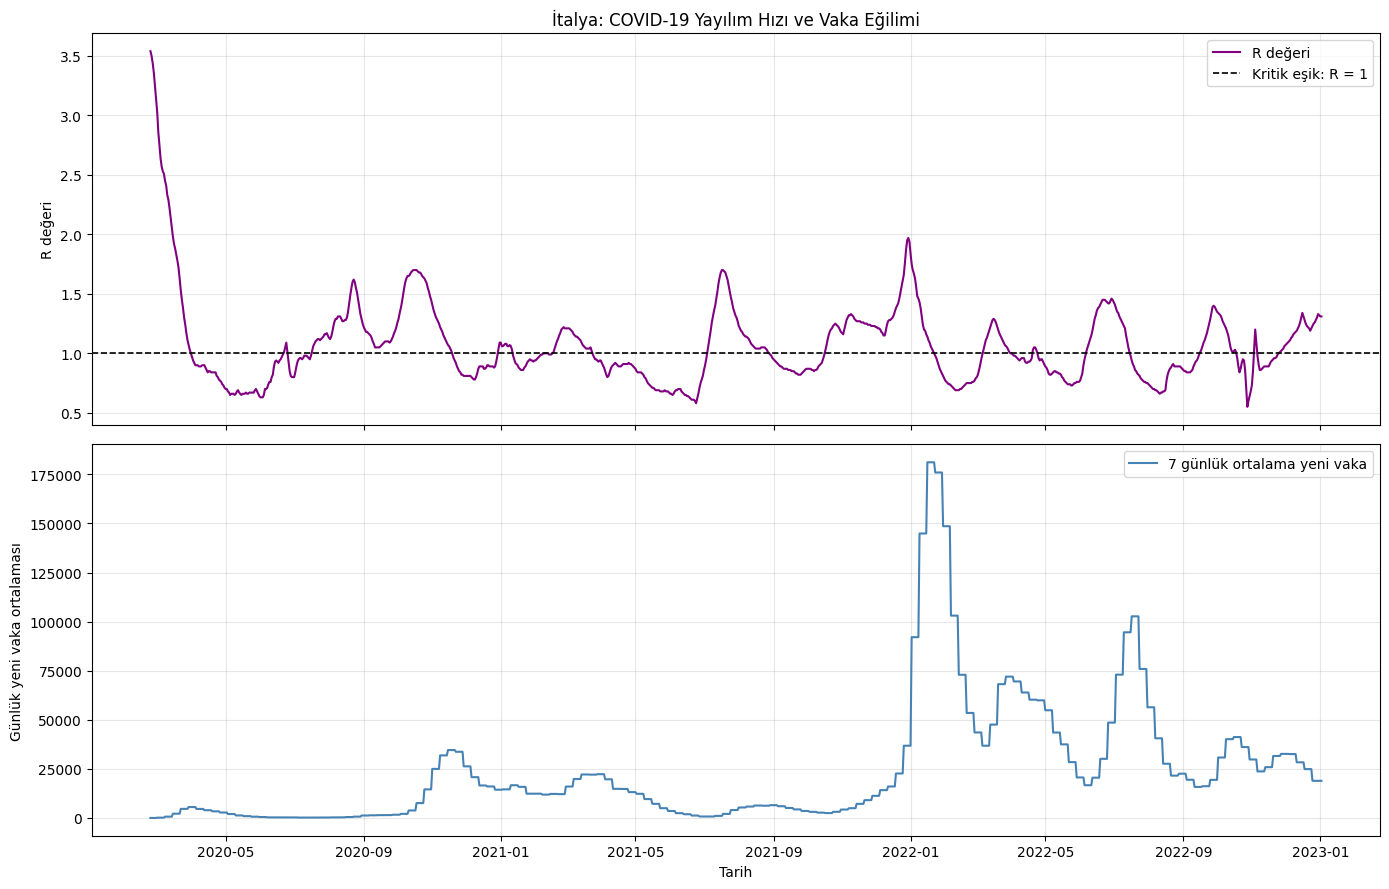

In [175]:
fig, (ax_r, ax_cases) = plt.subplots(
    2,
    1,
    figsize=(14, 9),
    sharex=True
)

# R değeri
ax_r.plot(
    italy_r_valid['date'],
    italy_r_valid['reproduction_rate'],
    color='purple',
    linewidth=1.5,
    label='R değeri'
)

ax_r.axhline(
    y=1,
    color='black',
    linestyle='--',
    linewidth=1.2,
    label='Kritik eşik: R = 1'
)

ax_r.set_title('İtalya: COVID-19 Yayılım Hızı ve Vaka Eğilimi')
ax_r.set_ylabel('R değeri')
ax_r.grid(alpha=0.3)
ax_r.legend()

# 7 günlük ortalama yeni vaka
ax_cases.plot(
    italy_r_valid['date'],
    italy_r_valid['new_cases_smoothed'],
    color='steelblue',
    linewidth=1.5,
    label='7 günlük ortalama yeni vaka'
)

ax_cases.set_xlabel('Tarih')
ax_cases.set_ylabel('Günlük yeni vaka ortalaması')
ax_cases.grid(alpha=0.3)
ax_cases.legend()

plt.tight_layout()
plt.show()

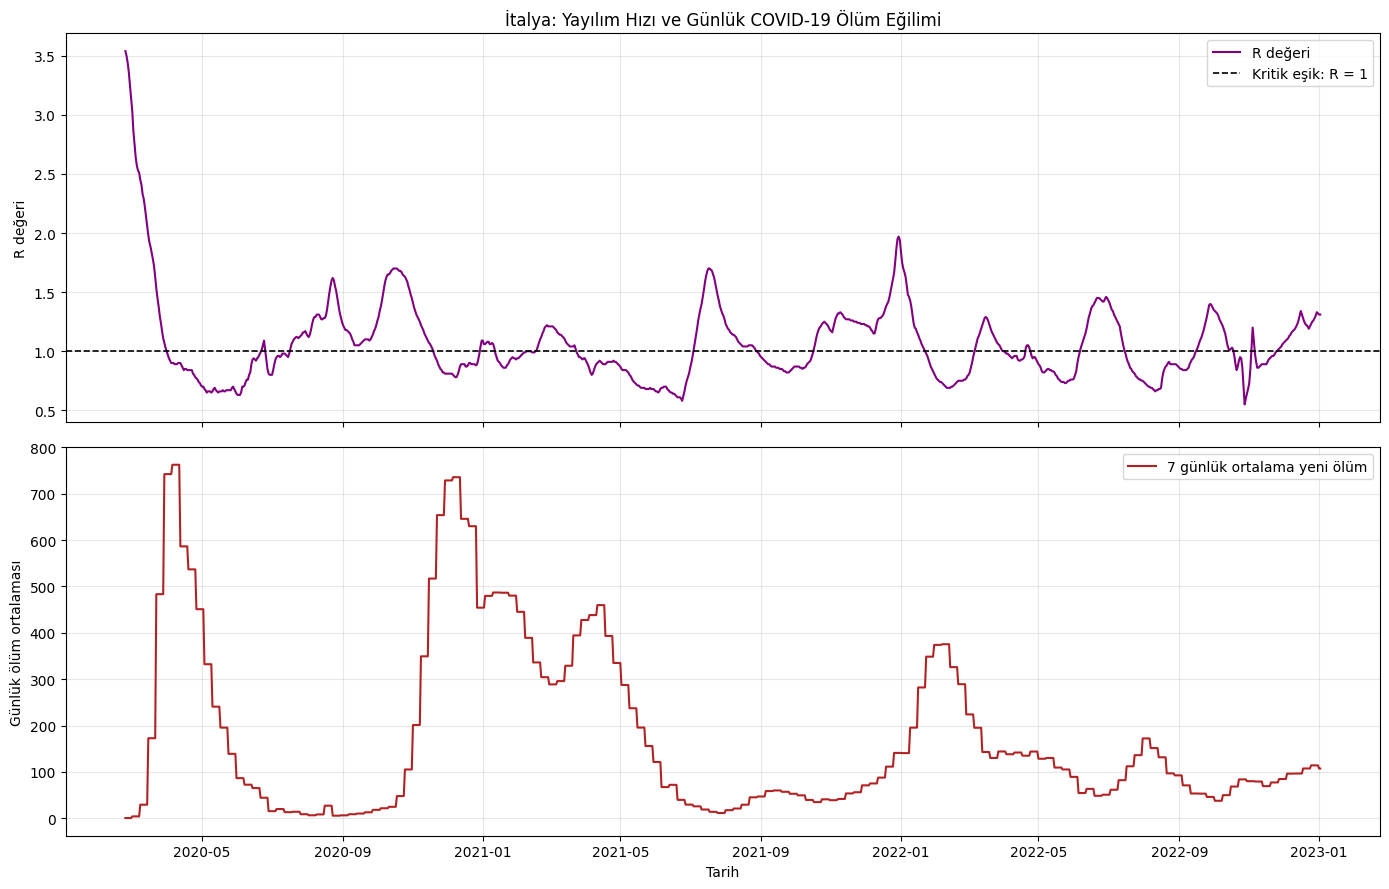

In [176]:
italy_r_death_data = (
    df_countries[
        df_countries['location'] == 'Italy'
    ][
        ['date', 'reproduction_rate', 'new_deaths_smoothed']
    ]
    .dropna(subset=['reproduction_rate'])
    .sort_values('date')
)

fig, (ax_r, ax_deaths) = plt.subplots(
    2,
    1,
    figsize=(14, 9),
    sharex=True
)

# R değeri
ax_r.plot(
    italy_r_death_data['date'],
    italy_r_death_data['reproduction_rate'],
    color='purple',
    linewidth=1.5,
    label='R değeri'
)

ax_r.axhline(
    y=1,
    color='black',
    linestyle='--',
    linewidth=1.2,
    label='Kritik eşik: R = 1'
)

ax_r.set_title('İtalya: Yayılım Hızı ve Günlük COVID-19 Ölüm Eğilimi')
ax_r.set_ylabel('R değeri')
ax_r.grid(alpha=0.3)
ax_r.legend()

# 7 günlük ortalama ölüm
ax_deaths.plot(
    italy_r_death_data['date'],
    italy_r_death_data['new_deaths_smoothed'],
    color='firebrick',
    linewidth=1.5,
    label='7 günlük ortalama yeni ölüm'
)

ax_deaths.set_xlabel('Tarih')
ax_deaths.set_ylabel('Günlük ölüm ortalaması')
ax_deaths.grid(alpha=0.3)
ax_deaths.legend()

plt.tight_layout()
plt.show()

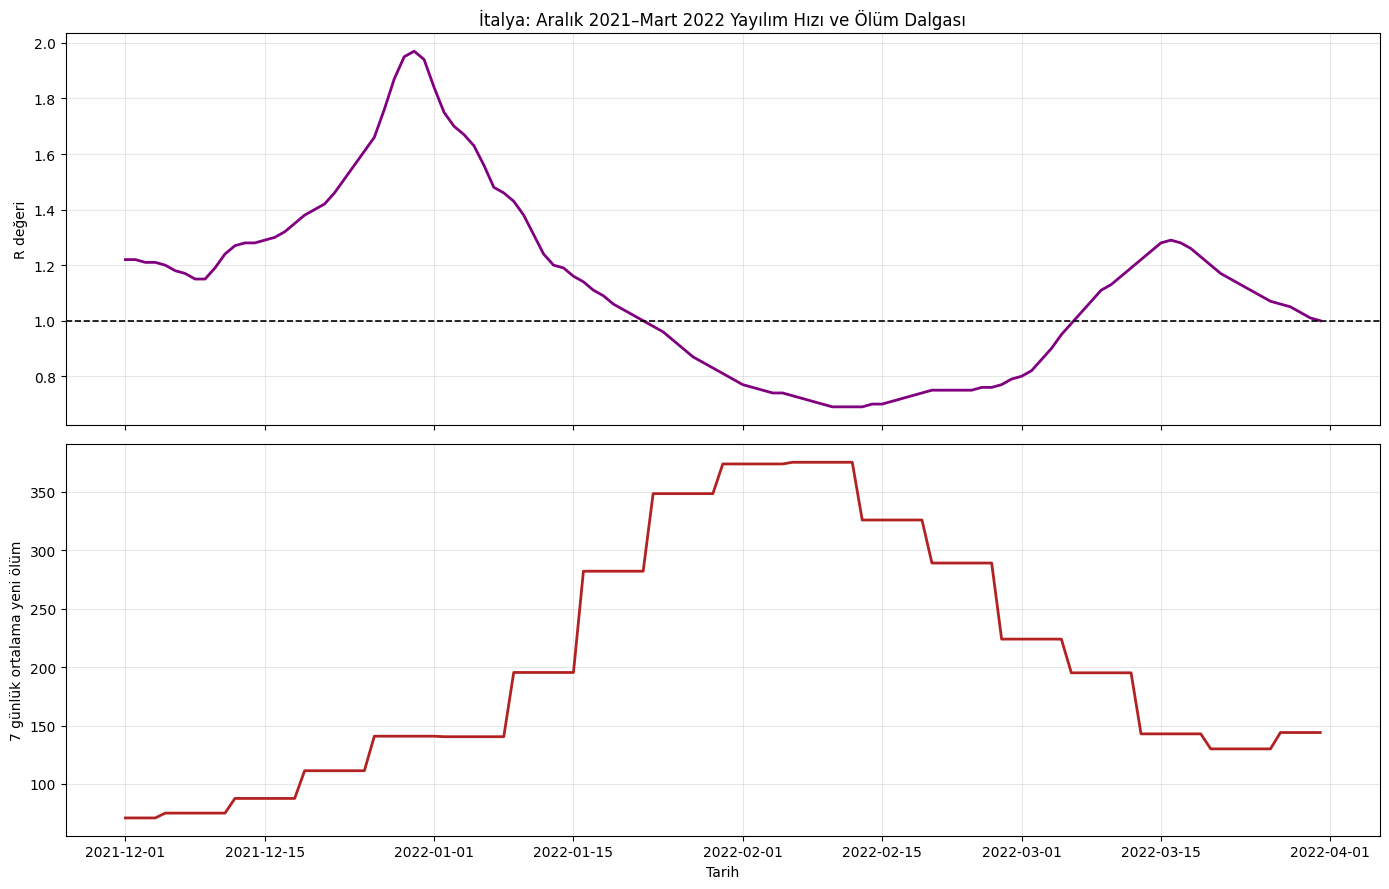

In [177]:
italy_wave = italy_r_death_data[
    (italy_r_death_data['date'] >= '2021-12-01')
    & (italy_r_death_data['date'] <= '2022-03-31')
]

fig, (ax_r, ax_deaths) = plt.subplots(
    2,
    1,
    figsize=(14, 9),
    sharex=True
)

ax_r.plot(
    italy_wave['date'],
    italy_wave['reproduction_rate'],
    color='purple',
    linewidth=2
)

ax_r.axhline(
    y=1,
    color='black',
    linestyle='--',
    linewidth=1.2
)

ax_r.set_title(
    'İtalya: Aralık 2021–Mart 2022 Yayılım Hızı ve Ölüm Dalgası'
)
ax_r.set_ylabel('R değeri')
ax_r.grid(alpha=0.3)

ax_deaths.plot(
    italy_wave['date'],
    italy_wave['new_deaths_smoothed'],
    color='firebrick',
    linewidth=2
)

ax_deaths.set_xlabel('Tarih')
ax_deaths.set_ylabel('7 günlük ortalama yeni ölüm')
ax_deaths.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [178]:
#stringency_index,hükümetin COVİD-19'a karşı aldığı önlemlerin ne kadar sıkı 
#olduğunu gösteren 0 ile 100 arası bir indextir.
stringency_coverage = (
    df_countries
    .groupby('location')
    .agg(
        toplam_satir=('date', 'size'),
        dolu_sikililik_kaydi=('stringency_index', 'count')
    )
)

valid_stringency_range = (
    df_countries[
        df_countries['stringency_index'].notna()
    ]
    .groupby('location')
    .agg(
        ilk_sikililik_tarihi=('date', 'min'),
        son_sikililik_tarihi=('date', 'max')
    )
)

stringency_coverage = stringency_coverage.join(
    valid_stringency_range
)

stringency_coverage['bos_sikililik_kaydi'] = (
    stringency_coverage['toplam_satir']
    - stringency_coverage['dolu_sikililik_kaydi']
)

print(
    stringency_coverage
    .sort_values('dolu_sikililik_kaydi', ascending=False)
    .head(20)
)

             toplam_satir  dolu_sikililik_kaydi ilk_sikililik_tarihi  \
location                                                               
Argentina            1678                  1096           2020-01-01   
Mexico               1678                  1096           2020-01-01   
Thailand             1675                  1093           2020-01-04   
Andorra              1674                  1092           2020-01-05   
Angola               1674                  1092           2020-01-05   
Albania              1674                  1092           2020-01-05   
Afghanistan          1674                  1092           2020-01-05   
Azerbaijan           1674                  1092           2020-01-05   
Bahamas              1674                  1092           2020-01-05   
Austria              1674                  1092           2020-01-05   
Australia            1674                  1092           2020-01-05   
Belarus              1674                  1092           2020-0

In [179]:
italy_stringency_data = (
    df_countries[
        df_countries['location'] == 'Italy'
    ][
        ['date', 'stringency_index', 'reproduction_rate', 'new_cases_smoothed']
    ]
    .sort_values('date')
)

italy_stringency_valid = italy_stringency_data[
    italy_stringency_data['stringency_index'].notna()
].copy()

expected_dates = pd.date_range(
    italy_stringency_valid['date'].min(),
    italy_stringency_valid['date'].max(),
    freq='D'
)

missing_stringency_dates = expected_dates.difference(
    italy_stringency_valid['date']
)

print('İlk stringency kaydı:', italy_stringency_valid['date'].min())
print('Son stringency kaydı:', italy_stringency_valid['date'].max())
print('Stringency kaydı bulunan gün:', len(italy_stringency_valid))
print('Aradaki eksik gün sayısı:', len(missing_stringency_dates))
print(missing_stringency_dates[:10])

İlk stringency kaydı: 2020-01-05 00:00:00
Son stringency kaydı: 2022-12-31 00:00:00
Stringency kaydı bulunan gün: 1092
Aradaki eksik gün sayısı: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


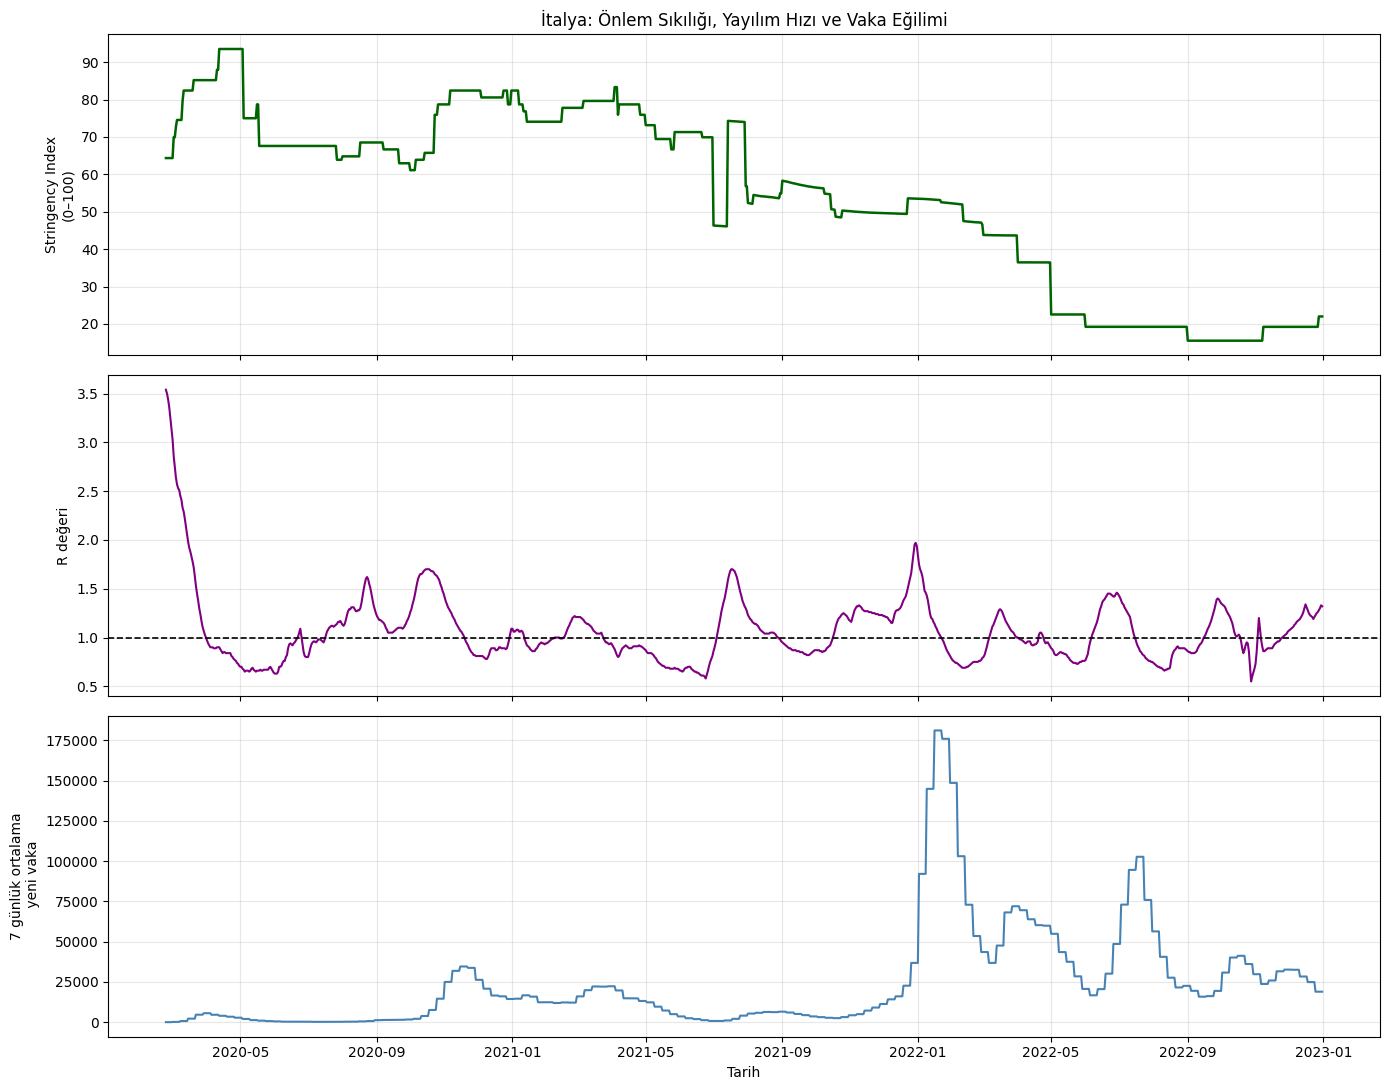

In [180]:
italy_policy_r_cases = (
    italy_stringency_data
    .dropna(
        subset=[
            'stringency_index',
            'reproduction_rate',
            'new_cases_smoothed'
        ]
    )
    .copy()
)

fig, (ax_policy, ax_r, ax_cases) = plt.subplots(
    3,
    1,
    figsize=(14, 11),
    sharex=True
)

# Önlem sıkılığı
ax_policy.plot(
    italy_policy_r_cases['date'],
    italy_policy_r_cases['stringency_index'],
    color='darkgreen',
    linewidth=1.8
)

ax_policy.set_title(
    'İtalya: Önlem Sıkılığı, Yayılım Hızı ve Vaka Eğilimi'
)
ax_policy.set_ylabel('Stringency Index\n(0–100)')
ax_policy.grid(alpha=0.3)

# R değeri
ax_r.plot(
    italy_policy_r_cases['date'],
    italy_policy_r_cases['reproduction_rate'],
    color='purple',
    linewidth=1.5
)

ax_r.axhline(
    y=1,
    color='black',
    linestyle='--',
    linewidth=1.2
)

ax_r.set_ylabel('R değeri')
ax_r.grid(alpha=0.3)

# 7 günlük ortalama vaka
ax_cases.plot(
    italy_policy_r_cases['date'],
    italy_policy_r_cases['new_cases_smoothed'],
    color='steelblue',
    linewidth=1.5
)

ax_cases.set_xlabel('Tarih')
ax_cases.set_ylabel('7 günlük ortalama\n yeni vaka')
ax_cases.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [194]:
admission_coverage = (
    df_countries
    .groupby('location')
    .agg(
        toplam_satir=('date', 'size'),
        dolu_haftalik_hastane_yatisi=(
            'weekly_hosp_admissions',
            'count'
        ),
        dolu_haftalik_yogun_bakim_yatisi=(
            'weekly_icu_admissions',
            'count'
        )
    )
)

admission_coverage['bos_haftalik_hastane_yatisi'] = (
    admission_coverage['toplam_satir']
    - admission_coverage['dolu_haftalik_hastane_yatisi']
)

admission_coverage['bos_haftalik_yogun_bakim_yatisi'] = (
    admission_coverage['toplam_satir']
    - admission_coverage['dolu_haftalik_yogun_bakim_yatisi']
)

print(
    admission_coverage
    .sort_values(
        'dolu_haftalik_hastane_yatisi',
        ascending=False
    )
    .head(20)
)

                toplam_satir  dolu_haftalik_hastane_yatisi  \
location                                                     
Czechia                 1682                          1618   
Malaysia                1684                          1591   
Italy                   1677                          1479   
United States           1674                          1375   
Germany                 1674                          1214   
Belgium                 1674                          1203   
Denmark                 1674                          1187   
Israel                  1674                          1156   
Chile                   1674                          1103   
France                  1674                          1102   
Spain                   1674                          1039   
Switzerland             1674                          1037   
Netherlands             1674                          1001   
United Kingdom          1674                           888   
South Ko

In [195]:
czechia_admissions = (
    df_countries[
        df_countries['location'] == 'Czechia'
    ][
        [
            'date',
            'weekly_hosp_admissions',
            'weekly_icu_admissions'
        ]
    ]
    .sort_values('date')
    .copy()
)

czechia_admissions_valid = czechia_admissions.dropna(
    subset=[
        'weekly_hosp_admissions',
        'weekly_icu_admissions'
    ]
).copy()

expected_dates = pd.date_range(
    czechia_admissions_valid['date'].min(),
    czechia_admissions_valid['date'].max(),
    freq='D'
)

missing_admission_dates = expected_dates.difference(
    czechia_admissions_valid['date']
)

print(
    'İlk iki yatış verisinin birlikte bulunduğu tarih:',
    czechia_admissions_valid['date'].min()
)
print(
    'Son iki yatış verisinin birlikte bulunduğu tarih:',
    czechia_admissions_valid['date'].max()
)
print(
    'Birlikte veri bulunan gün sayısı:',
    len(czechia_admissions_valid)
)
print(
    'Aradaki eksik gün sayısı:',
    len(missing_admission_dates)
)
print(missing_admission_dates[:10])

İlk iki yatış verisinin birlikte bulunduğu tarih: 2020-03-07 00:00:00
Son iki yatış verisinin birlikte bulunduğu tarih: 2024-08-10 00:00:00
Birlikte veri bulunan gün sayısı: 1618
Aradaki eksik gün sayısı: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


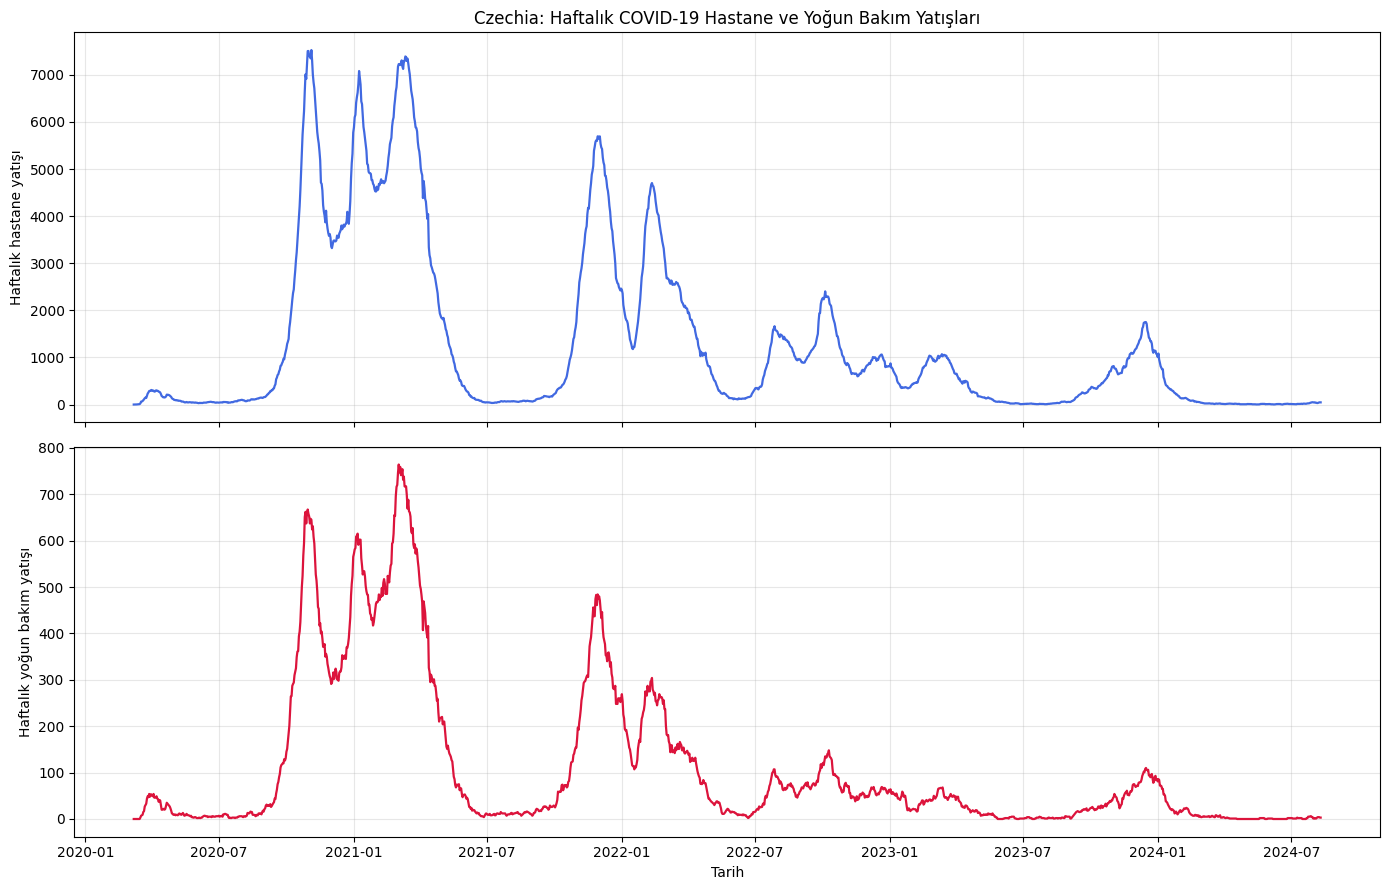

In [196]:
fig, (ax_hosp, ax_icu) = plt.subplots(
    2,
    1,
    figsize=(14, 9),
    sharex=True
)

ax_hosp.plot(
    czechia_admissions_valid['date'],
    czechia_admissions_valid['weekly_hosp_admissions'],
    color='royalblue',
    linewidth=1.6
)

ax_hosp.set_title(
    'Czechia: Haftalık COVID-19 Hastane ve Yoğun Bakım Yatışları'
)
ax_hosp.set_ylabel('Haftalık hastane yatışı')
ax_hosp.grid(alpha=0.3)

ax_icu.plot(
    czechia_admissions_valid['date'],
    czechia_admissions_valid['weekly_icu_admissions'],
    color='crimson',
    linewidth=1.6
)

ax_icu.set_xlabel('Tarih')
ax_icu.set_ylabel('Haftalık yoğun bakım yatışı')
ax_icu.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [197]:
czechia_admission_ratio = (
    czechia_admissions_valid[
        czechia_admissions_valid[
            'weekly_hosp_admissions'
        ] > 0
    ]
    .copy()
)

czechia_admission_ratio['yogun_bakim_yatis_orani'] = (
    czechia_admission_ratio['weekly_icu_admissions']
    / czechia_admission_ratio['weekly_hosp_admissions']
    * 100
)

print(
    czechia_admission_ratio[
        [
            'date',
            'weekly_hosp_admissions',
            'weekly_icu_admissions',
            'yogun_bakim_yatis_orani'
        ]
    ]
    .head()
)

            date  weekly_hosp_admissions  weekly_icu_admissions  \
88792 2020-03-11                     2.0                    0.0   
88793 2020-03-12                     3.0                    0.0   
88794 2020-03-13                     6.0                    0.0   
88795 2020-03-14                     7.0                    0.0   
88796 2020-03-15                     9.0                    0.0   

       yogun_bakim_yatis_orani  
88792                      0.0  
88793                      0.0  
88794                      0.0  
88795                      0.0  
88796                      0.0  


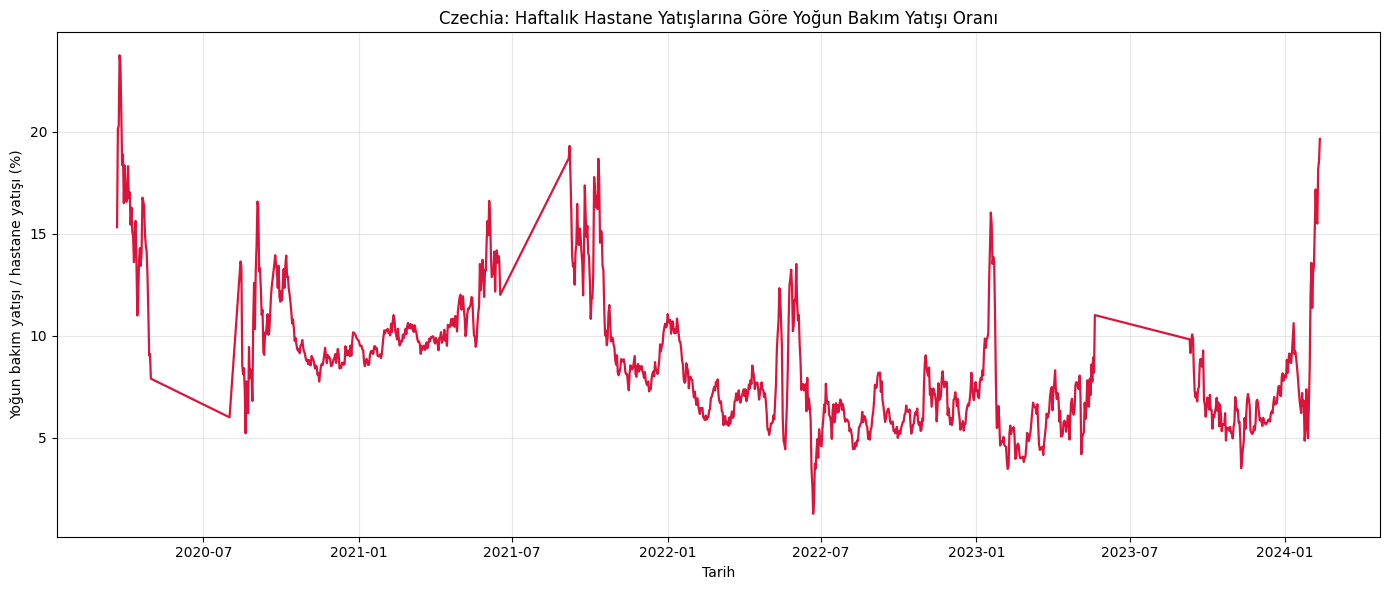

In [198]:
czechia_ratio_plot = czechia_admission_ratio[
    czechia_admission_ratio['weekly_hosp_admissions'] >= 100
].copy()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    czechia_ratio_plot['date'],
    czechia_ratio_plot['yogun_bakim_yatis_orani'],
    color='crimson',
    linewidth=1.6
)

ax.set_title(
    'Czechia: Haftalık Hastane Yatışlarına Göre Yoğun Bakım Yatışı Oranı'
)
ax.set_xlabel('Tarih')
ax.set_ylabel('Yoğun bakım yatışı / hastane yatışı (%)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

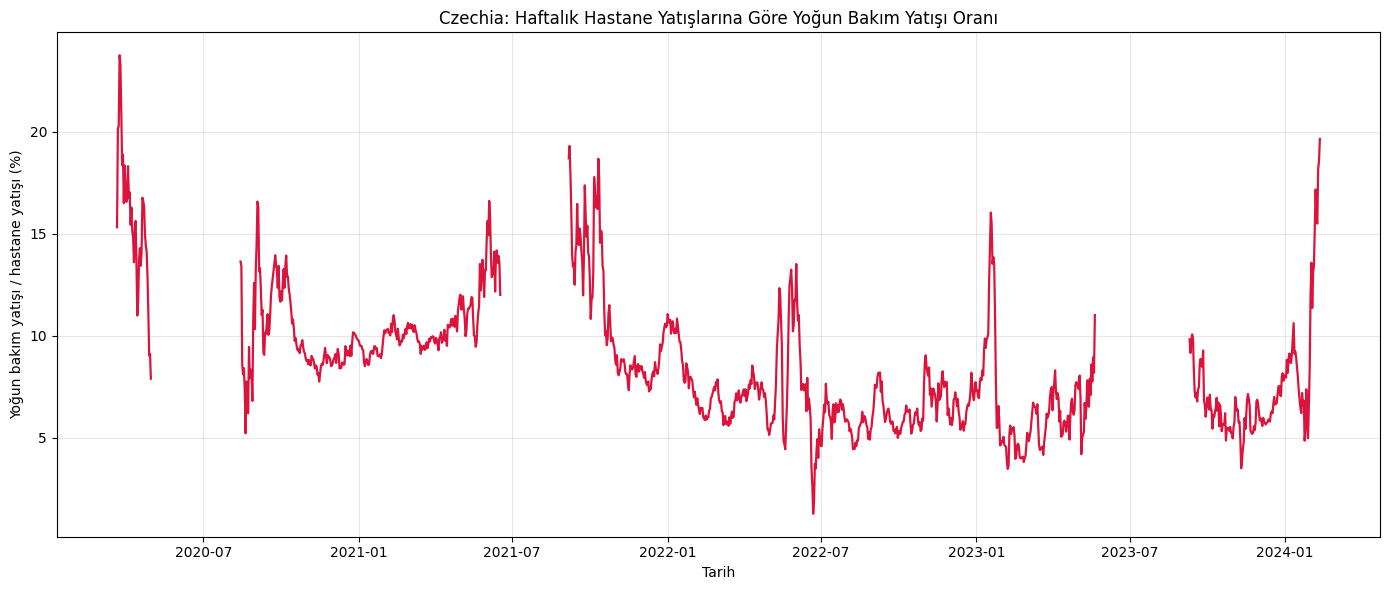

In [199]:
czechia_ratio_plot = czechia_admission_ratio.copy()

czechia_ratio_plot['gosterilecek_yogun_bakim_orani'] = (
    czechia_ratio_plot['yogun_bakim_yatis_orani']
    .where(
        czechia_ratio_plot['weekly_hosp_admissions'] >= 100
    )
)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    czechia_ratio_plot['date'],
    czechia_ratio_plot['gosterilecek_yogun_bakim_orani'],
    color='crimson',
    linewidth=1.6
)

ax.set_title(
    'Czechia: Haftalık Hastane Yatışlarına Göre Yoğun Bakım Yatışı Oranı'
)
ax.set_xlabel('Tarih')
ax.set_ylabel('Yoğun bakım yatışı / hastane yatışı (%)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [225]:
admission_per_million_coverage = (
    df_countries
    .groupby('location')
    .agg(
        toplam_satir=('date', 'size'),
        dolu_hastane_yatisi_milyon=(
            'weekly_hosp_admissions_per_million',
            'count'
        ),
        dolu_yogun_bakim_yatisi_milyon=(
            'weekly_icu_admissions_per_million',
            'count'
        )
    )
)

admission_per_million_coverage[
    'bos_hastane_yatisi_milyon'
] = (
    admission_per_million_coverage['toplam_satir']
    - admission_per_million_coverage[
        'dolu_hastane_yatisi_milyon'
    ]
)

admission_per_million_coverage[
    'bos_yogun_bakim_yatisi_milyon'
] = (
    admission_per_million_coverage['toplam_satir']
    - admission_per_million_coverage[
        'dolu_yogun_bakim_yatisi_milyon'
    ]
)

print(
    admission_per_million_coverage
    .sort_values(
        'dolu_hastane_yatisi_milyon',
        ascending=False
    )
    .head(20)
)

                toplam_satir  dolu_hastane_yatisi_milyon  \
location                                                   
Czechia                 1682                        1618   
Malaysia                1684                        1591   
Italy                   1677                        1479   
United States           1674                        1375   
Germany                 1674                        1214   
Belgium                 1674                        1203   
Denmark                 1674                        1187   
Israel                  1674                        1156   
Chile                   1674                        1103   
France                  1674                        1102   
Spain                   1674                        1039   
Switzerland             1674                        1037   
Netherlands             1674                        1001   
United Kingdom          1674                         888   
South Korea             1674            

In [226]:
admission_per_million_date_coverage = (
    df_countries[
        df_countries[
            'weekly_hosp_admissions_per_million'
        ].notna()
        & df_countries[
            'weekly_icu_admissions_per_million'
        ].notna()
    ]
    .groupby('date')['location']
    .nunique()
    .sort_values(ascending=False)
)

print(admission_per_million_date_coverage.head(10))

date
2021-12-05    18
2021-11-14    18
2021-09-26    18
2021-10-10    18
2021-10-24    18
2021-08-29    18
2021-09-05    18
2021-09-19    18
2021-12-26    18
2021-08-08    18
Name: location, dtype: int64


In [227]:
selected_admission_date = pd.Timestamp('2021-12-05')

admission_per_million_comparison = (
    df_countries[
        df_countries['date'] == selected_admission_date
    ][
        [
            'location',
            'weekly_hosp_admissions_per_million',
            'weekly_icu_admissions_per_million'
        ]
    ]
    .dropna()
    .sort_values(
        'weekly_hosp_admissions_per_million'
    )
    .copy()
)

print(admission_per_million_comparison.to_string(index=False))

   location  weekly_hosp_admissions_per_million  weekly_icu_admissions_per_million
     Israel                               11.22                               0.74
      Malta                               17.27                               3.84
     Norway                               40.44                               8.35
      Chile                               42.64                              12.91
      Italy                               59.47                               6.83
      Spain                               72.06                              12.13
    Ireland                               75.30                               7.12
     Cyprus                               77.37                              13.26
 Luxembourg                               89.87                              24.79
     France                               94.20                              20.68
    Estonia                              112.63                              14.27
Neth

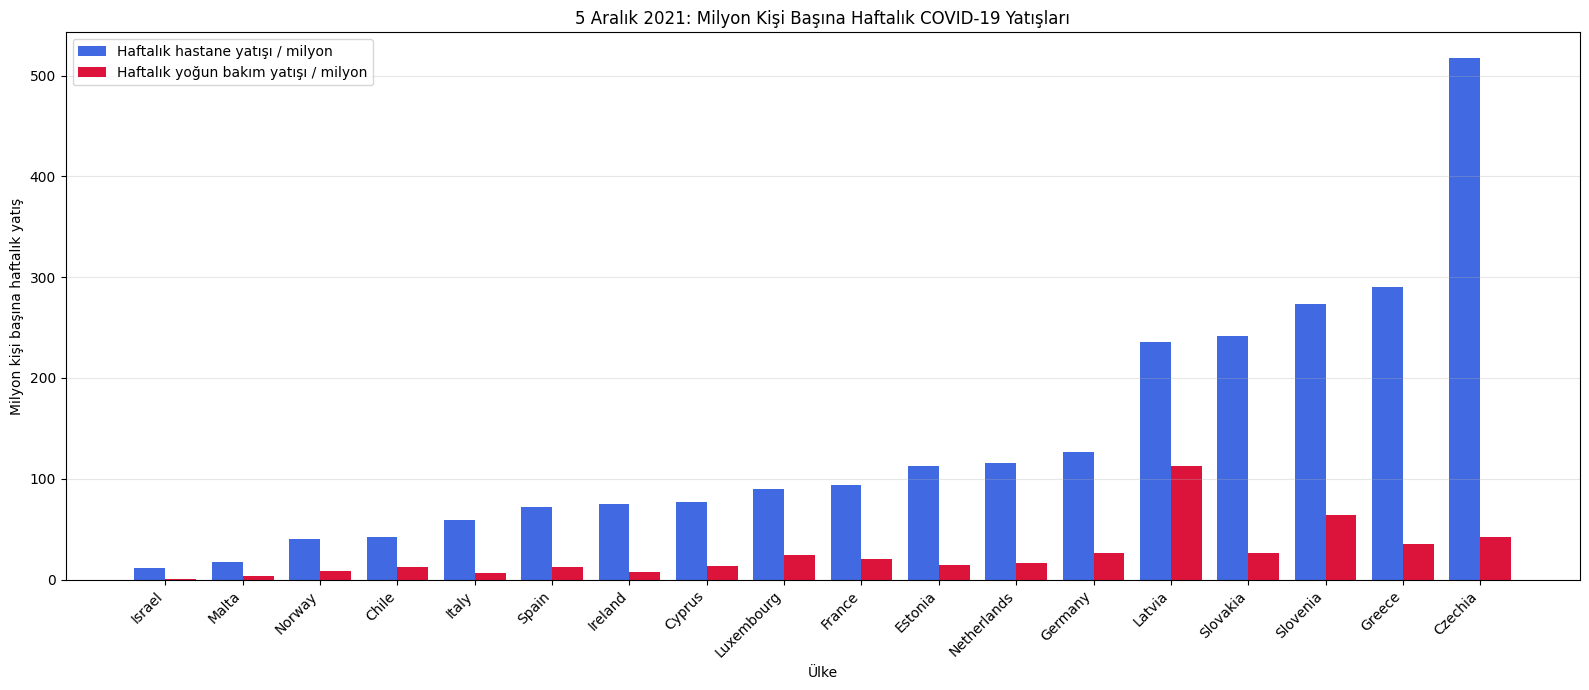

In [229]:
x = np.arange(len(admission_per_million_comparison))
bar_width = 0.4

fig, ax = plt.subplots(figsize=(16, 7))

ax.bar(
    x - bar_width / 2,
    admission_per_million_comparison[
        'weekly_hosp_admissions_per_million'
    ],
    width=bar_width,
    color='royalblue',
    label='Haftalık hastane yatışı / milyon'
)

ax.bar(
    x + bar_width / 2,
    admission_per_million_comparison[
        'weekly_icu_admissions_per_million'
    ],
    width=bar_width,
    color='crimson',
    label='Haftalık yoğun bakım yatışı / milyon'
)

ax.set_title(
    '5 Aralık 2021: Milyon Kişi Başına Haftalık COVID-19 Yatışları'
)
ax.set_xlabel('Ülke')
ax.set_ylabel('Milyon kişi başına haftalık yatış')
ax.set_xticks(x)
ax.set_xticklabels(
    admission_per_million_comparison['location'],
    rotation=45,
    ha='right'
)
ax.grid(axis='y', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()